In [22]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import grad, vmap, random
import equinox as eqx
import optax
import diffrax
from seaborn import kdeplot
import wandb
from ot.lp import wasserstein_1d as wd
import argparse
import pickle

plt.style.use("ggplot")

In [4]:
class MLP(eqx.Module):
    layers: list
    def __init__(self, key, dim, out_dim=None, w=64):
        super().__init__()
        key1, key2, key3, key4 = random.split(key, 4)
        if out_dim is None:
            out_dim = dim - 1

        self.layers = [
            eqx.nn.Linear(dim, w, key=key1),
            jax.nn.gelu,
            eqx.nn.Linear(w, w, key=key2),
            jax.nn.gelu,
            eqx.nn.Linear(w, w, key=key3),
            jax.nn.gelu,
            eqx.nn.Linear(w, out_dim, key=key4),
        ]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

In [14]:
@eqx.filter_jit
def transport_loss(model, u, y_xi):
    vmap_model = vmap(model)
    transport = vmap_model(y_xi)
    error = transport - u
    loss = jnp.mean((error) * (error))
    return loss

In [49]:
def dataloader(data, batch_size, train_dim, *, key):
    indices = jnp.arange(train_dim)
    while True:
        key, subkey = random.split(key=key, num=2)
        perm = random.permutation(subkey, indices)
        start = 0
        end = batch_size
        while end < train_dim:
            batch_perm = perm[start:end]
            yield data[batch_perm]
            start = end
            end = start + batch_size

In [52]:
def transport_trainer(target_data, train_dim, model, optimizer, batch_size, steps, print_every):
    @eqx.filter_jit
    def make_step(model, opt_state, u, y_xi):
        loss_value, grads = eqx.filter_value_and_grad(transport_loss)(
            model, u, y_xi
        )
        updates, opt_state = optimizer.update(grads, opt_state, model)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss_value
        
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))
    dataloader_key = random.key(np.random.choice(10000))
    target_loader = dataloader(
        target_data,
        batch_size,
        train_dim,
        key=dataloader_key,
    )

    for data, step in zip(target_loader, tqdm(range(steps))):
        y_xi = data[:, 0:2]
        us = data[:, 2:3]
        model, opt_state, train_loss = make_step(
            model,
            opt_state,
            us,
            y_xi,
        )
        if (step % print_every) == 0 or (step == steps - 1):
            print(f"{step = }, train_loss = {train_loss.item()}")

    return model

In [ ]:
key = random.key(22)
keys = random.split(key, 2)
transport_model = MLP(key, 2)
optimizer = optax.adamw(1e-3)
train_dim = 512
epochs = 400
batch_size = 2048
batch_size = min(batch_size, train_dim)
batch_size -= 1
steps_per_epoch = int(np.ceil(train_dim / batch_size))
steps = steps_per_epoch * epochs
print_every = 5000
ys = random.uniform(keys[0], shape=(train_dim, 1), minval=-3.0, maxval=3.0)
xi = 0.3 * (random.exponential(key=keys[1], shape=(train_dim, 1)))
us = jnp.tanh(ys) + xi
target_data = jnp.hstack([ys, xi, us])

transport = transport_trainer(target_data, train_dim, transport_model, optimizer, batch_size, steps, print_every)

 10%|█         | 81/800 [00:01<00:08, 80.24it/s]

step = 0, train_loss = 0.8391257524490356


100%|██████████| 800/800 [00:02<00:00, 344.60it/s]

step = 799, train_loss = 5.1214890845585614e-05


In [87]:
key1, key2 = random.split(key)
ys = 2.0 * jnp.ones((50000, 1))
xi = 0.3 * (random.exponential(key=key2, shape=(50000, 1)))
us = jnp.tanh(ys) + xi
y_xi = jnp.hstack([ys, xi])
us_gen = vmap(transport)(y_xi)

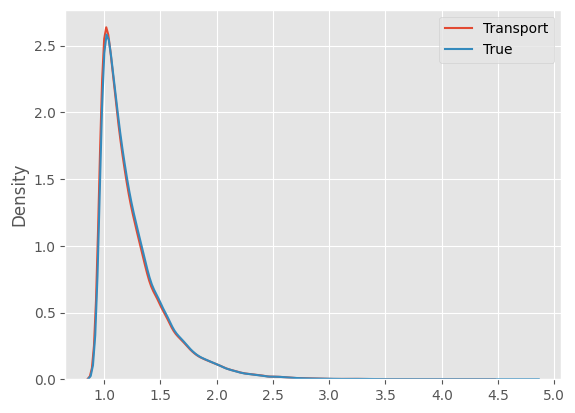

In [88]:
kdeplot(us_gen.squeeze(), label="Transport")
kdeplot(us.squeeze(), label="True")
plt.legend()

In [89]:
wd(np.array(us_gen.squeeze()), np.array(us.squeeze()), p=2)

np.float32(7.079689e-05)

In [25]:
jnp.sort((us_gen - us).squeeze())

Array([-0.02303934, -0.01257324, -0.00700474, ...,  0.00129867,
        0.00129938,  0.00131297], dtype=float32)